In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving BW.jpg to BW.jpg


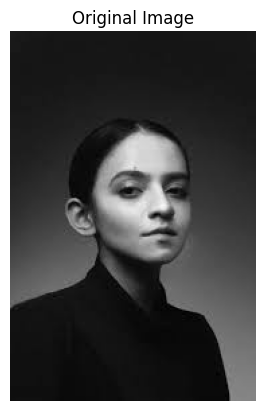

In [3]:
#Read Image
filename = next(iter(uploaded))

img = cv2.imread(filename)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
#Create Sharpening Kernel
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

print(kernel)

[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


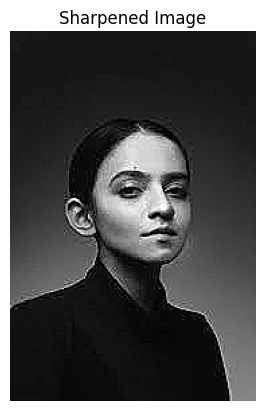

In [20]:
#Sharpen Image
sharpened = cv2.filter2D(img_rgb, -1, kernel)

plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

In [6]:
#Choose A
A = 2

original = img_rgb.astype(np.float32)
sharpened = sharpened.astype(np.float32)
#High-Boost Formula
high_boost = (A - 1) * original + sharpened

high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

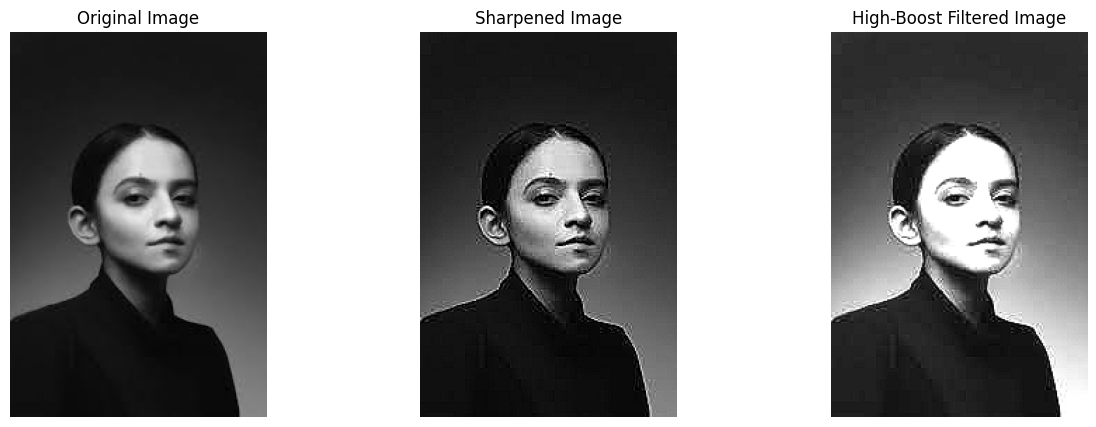

In [7]:
#Display Result
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sharpened.astype(np.uint8))
plt.title("Sharpened Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(high_boost)
plt.title("High-Boost Filtered Image")
plt.axis("off")

plt.show()

In [11]:
#Original Image

#Convert to Grayscale

#Find Dark and Bright Regions

#Dark Region → γ = 0.5
#Bright Region → γ = 1.5

#Combine Both Regions

#Enhanced Image

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [13]:
uploaded = files.upload()

Saving BW.jpg to BW (1).jpg


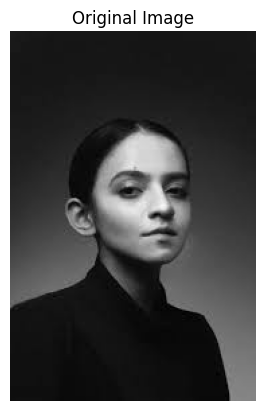

In [14]:
#Original Image
filename = next(iter(uploaded))

img = cv2.imread(filename)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

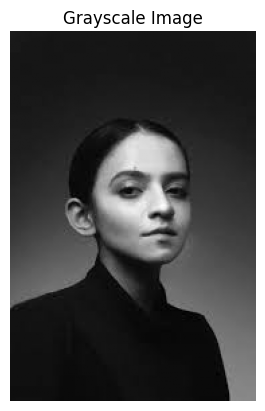

In [15]:
#Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [16]:
#Find Dark and Bright Regions
dark_mask = gray < 128
bright_mask = gray >= 128

print("Dark pixels:", np.sum(dark_mask))
print("Bright pixels:", np.sum(bright_mask))

Dark pixels: 46382
Bright pixels: 3943


In [17]:
#Dark Region → γ = 0.5
#Bright Region → γ = 1.5
gamma_dark = 0.5
gamma_bright = 1.5

print("Gamma for dark region:", gamma_dark)
print("Gamma for bright region:", gamma_bright)

Gamma for dark region: 0.5
Gamma for bright region: 1.5


In [18]:
#Combine Both Regions
normalized = gray / 255.0

dark_corrected = np.power(normalized, gamma_dark)

bright_corrected = np.power(normalized, gamma_bright)

result = np.zeros_like(normalized)

result[dark_mask] = dark_corrected[dark_mask]
result[bright_mask] = bright_corrected[bright_mask]

result = np.clip(result * 255, 0, 255).astype(np.uint8)

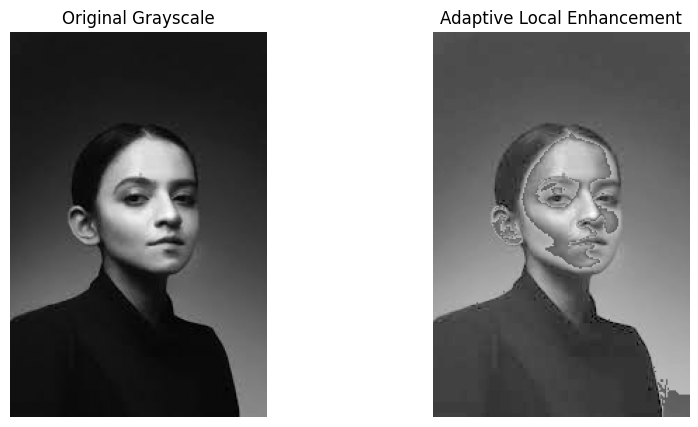

In [19]:
#Enhanced Image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Adaptive Local Enhancement")
plt.axis("off")

plt.show()